In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)


In [2]:
# Load California Housing Dataset

housing = fetch_california_housing()

X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target)

# Display first 5 rows
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
# Dataset shape

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (20640, 8)
Target Shape: (20640,)


In [4]:
# Check missing values

print(X.isnull().sum())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


In [5]:
# Apply StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818


In [6]:
# Split dataset into training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (16512, 8)
Testing Data: (4128, 8)


In [7]:
# Train Linear Regression Model

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

# Predictions
y_pred_linear = linear_model.predict(X_test)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [8]:
# Train Ridge Regression

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

# Predictions
y_pred_ridge = ridge_model.predict(X_test)

print("Ridge Regression Model Trained Successfully")

Ridge Regression Model Trained Successfully


In [9]:
# Train Decision Tree Regressor

tree_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

# Predictions
y_pred_tree = tree_model.predict(X_test)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [10]:
# Function to evaluate models

def evaluate_model(y_true, y_pred, model_name):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"Model: {model_name}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2 Score : {r2:.4f}")
    print("-" * 40)

    return rmse, r2

In [11]:
# Evaluate Linear Regression

linear_rmse, linear_r2 = evaluate_model(
    y_test,
    y_pred_linear,
    "Linear Regression"
)

# Evaluate Ridge Regression

ridge_rmse, ridge_r2 = evaluate_model(
    y_test,
    y_pred_ridge,
    "Ridge Regression"
)

# Evaluate Decision Tree

tree_rmse, tree_r2 = evaluate_model(
    y_test,
    y_pred_tree,
    "Decision Tree Regressor"
)

Model: Linear Regression
RMSE : 0.7456
R2 Score : 0.5758
----------------------------------------
Model: Ridge Regression
RMSE : 0.7456
R2 Score : 0.5758
----------------------------------------
Model: Decision Tree Regressor
RMSE : 0.7242
R2 Score : 0.5997
----------------------------------------


In [12]:
# Create comparison dataframe

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Decision Tree"
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        tree_rmse
    ],
    "R2 Score": [
        linear_r2,
        ridge_r2,
        tree_r2
    ]
})

comparison

,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745554,0.575819
2,Decision Tree,0.724234,0.599732


In [14]:
# Find best model

best_model = comparison.sort_values(
    by="R2 Score",
    ascending=True
)

best_model

,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745554,0.575819
2,Decision Tree,0.724234,0.599732


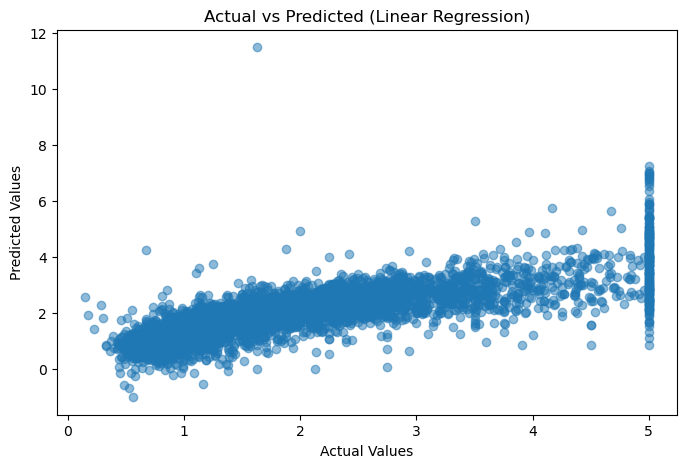

In [15]:
# Plot Actual vs Predicted values

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.5
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Linear Regression)")

plt.show()

In [16]:
# Feature importance from Decision Tree

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,MedInc,0.771212
5,AveOccup,0.128407
1,HouseAge,0.041621
2,AveRooms,0.031261
6,Latitude,0.022049
4,Population,0.002485
7,Longitude,0.002097
3,AveBedrms,0.000869


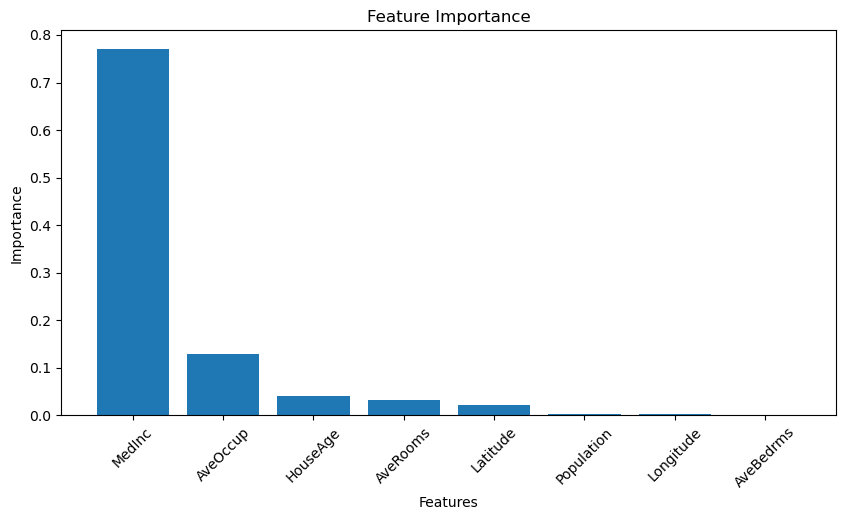

In [17]:
# Plot feature importance

plt.figure(figsize=(10,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()